### **Post Lab Task:** Implement ANN on Titanic Dataset.

Training network using: adam ...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training network using: sgd ...
Training network using: rmsprop ...

Test Loss: 0.4184640944004059
Test Accuracy: 0.826815664768219


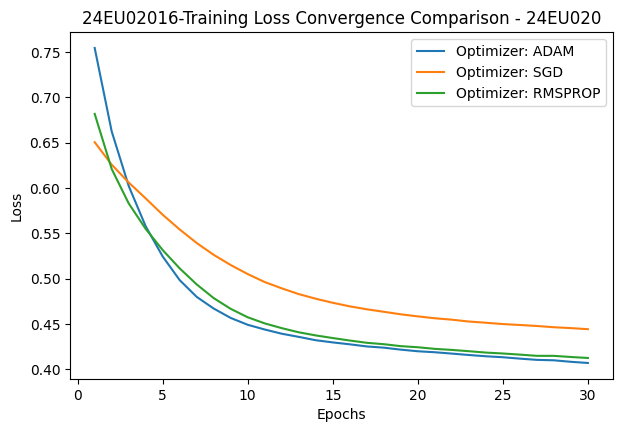

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load Titanic dataset
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

# Select required columns
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]

# Handle missing values and encode Sex
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Separate input and output
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize data
scaler = StandardScaler()
X_train_p = scaler.fit_transform(X_train)
X_test_p = scaler.transform(X_test)
y_train_p = y_train
y_test_p = y_test

# Build ANN model
def build_ann_model(optimizer_name='adam'):
    model = Sequential([
        Dense(16, activation='relu', input_shape=(X_train_p.shape[1],)),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=optimizer_name, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Train ANN with different optimizers
optimizers = ['adam', 'sgd', 'rmsprop']
history_records = {}

for opt in optimizers:
    print("Training network using:", opt, "...")
    temp_model = build_ann_model(optimizer_name=opt)
    hist = temp_model.fit(X_train_p, y_train_p, validation_split=0.2, epochs=30, batch_size=16, verbose=0)
    history_records[opt] = hist.history['loss']

# Evaluate final model
model = build_ann_model('adam')
model.fit(X_train_p, y_train_p, epochs=30, batch_size=16, verbose=0)
loss, accuracy = model.evaluate(X_test_p, y_test_p, verbose=0)

print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)

# Plot training loss comparison
plt.figure(figsize=(7, 4.5))

for opt in optimizers:
    plt.plot(range(1, 31), history_records[opt], label="Optimizer: " + opt.upper())

plt.title("24EU02016-Training Loss Convergence Comparison - 24EU020")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()